## SPAD Position Optimization Sweep

This notebook connects to the running qudi instance and performs a **two-phase**
position optimization using `spad_optimize_logic`:

1. **Z sweep** — find the optimal focus by sweeping Z and tracking the 9 brightest
   pixels (one per emitter in the 3×3 array).  The scanner is then moved to the
   peak-Z position.
2. **XY sweep** — at the optimal Z, sweep XY and compute the integrated 9-emitter
   counts using a fixed 5×5-footprint mask (every-other-pixel spacing) anchored to
   the brightest pixel found during the Z sweep.

The feedback between phases ensures the XY sweep is performed at best focus.

**Prerequisites:**
- qudi is running with `spad_optimize_logic`, `spad_probe_logic`, and `camera_SPC3` activated
- The SPC3 camera live view is **stopped** (snap mode requires it)
- Optimizer settings (scan range, resolution) are configured in `scanner_spad_gui`
- The scanner is positioned at the approximate centre of the region of interest

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Access qudi modules (available in the kernel namespace)
opt      = spad_optimize_logic
spad     = spad_probe_logic
cam      = camera_SPC3
cam_logic = camera_logic

print(f'Scanner position : {dict(spad.scanner_target)}')
print(f'Optimizer running: {opt.optimizer_running}')

Scanner position : {'x': 0.0001346253, 'y': 7.17108e-05, 'z': 0.0001556784}
Optimizer running: False


## Inspect / override optimizer settings

The sweep uses the optimizer settings that are already configured in `scanner_spad_gui`.
You can inspect them below and optionally override range or resolution before starting.

In [2]:
# Current optimizer settings (set via scanner_spad_gui)
print('Scan sequence :', opt.scan_sequence)
print('Scan range    :', {k: f'{v*1e6:.2f} µm' for k, v in opt.scan_range.items()})
print('Number of points:', opt.scan_resolution)
#print('Data channel  :', opt.data_channel)
print('NFrames       :', cam._NFrames, ' (frames averaged per position)')
exposure_ms = float(cam.get_exposure()) * 1e3
print('Exposure     :', f'{exposure_ms:.2f} ms' if exposure_ms is not None else '<unavailable>')

# --- Optional: override optimizer settings from notebook ---
# Uncomment and adjust as needed:
#
# opt.set_optimize_settings(
#     data_channel='APD1',
#     scan_sequence=(('x', 'y'), ('z',)),
#     scan_dimension=[2, 1],
#     range={'x': 10e-6, 'y': 10e-6, 'z': 5e-6},     # sweep range per axis (m)
#     resolution={'x': 20, 'y': 20, 'z': 15},          # points per axis
#     frequency={'x': 50, 'y': 50, 'z': 50},            # not used for SPAD sweep, kept for GUI compat
# )

Scan sequence : (('x', 'y'),)
Scan range    : {'x': '0.30 µm', 'y': '0.30 µm', 'z': '5.00 µm'}
Number of points: {'x': 10, 'y': 10, 'z': 100}
NFrames       : 5  (frames averaged per position)
Exposure     : 104.00 ms


## Phase 1 — Z Focus Sweep

Override the scan sequence to Z-only, run the sweep, and find the optimal focus.

The optimizer will:
1. Set `trigger_mode='no_trigger'` on the SPC3
2. Step through the Z grid, snapping NFrames at each position
3. Restore trigger mode and return scanner to the starting position

In [3]:
# Set sequence to Z-only
opt.scan_sequence = (('z',),)
opt.optimizer_sequence_dimensions = (1,)  # ensure GUI has a 1D widget for ('z',)
print('Scan sequence set to:', opt.scan_sequence)

# Start Z sweep
opt.start_optimize()

t0 = time.time()
while opt.optimizer_running:
    time.sleep(0.5)
    elapsed = time.time() - t0
    print(f'\rZ sweep running... {elapsed:.0f}s', end='', flush=True)

elapsed = time.time() - t0
print(f'\nZ sweep complete in {elapsed:.1f}s')

Scan sequence set to: (('z',),)
Z sweep running... 80s
Z sweep complete in 79.6s


## Retrieve & analyse Z sweep

Find the optimal Z by plotting the sum of the 9 brightest pixels vs Z position.
The brightest pixel in the peak-Z frame identifies the centre of the 3×3 emitter
array and will be used as the mask anchor for the XY sweep.

### Z analysis & move to optimal focus

Z sweep: 153.18 – 158.18 µm, 100 points, frames shape (100, 32, 32)


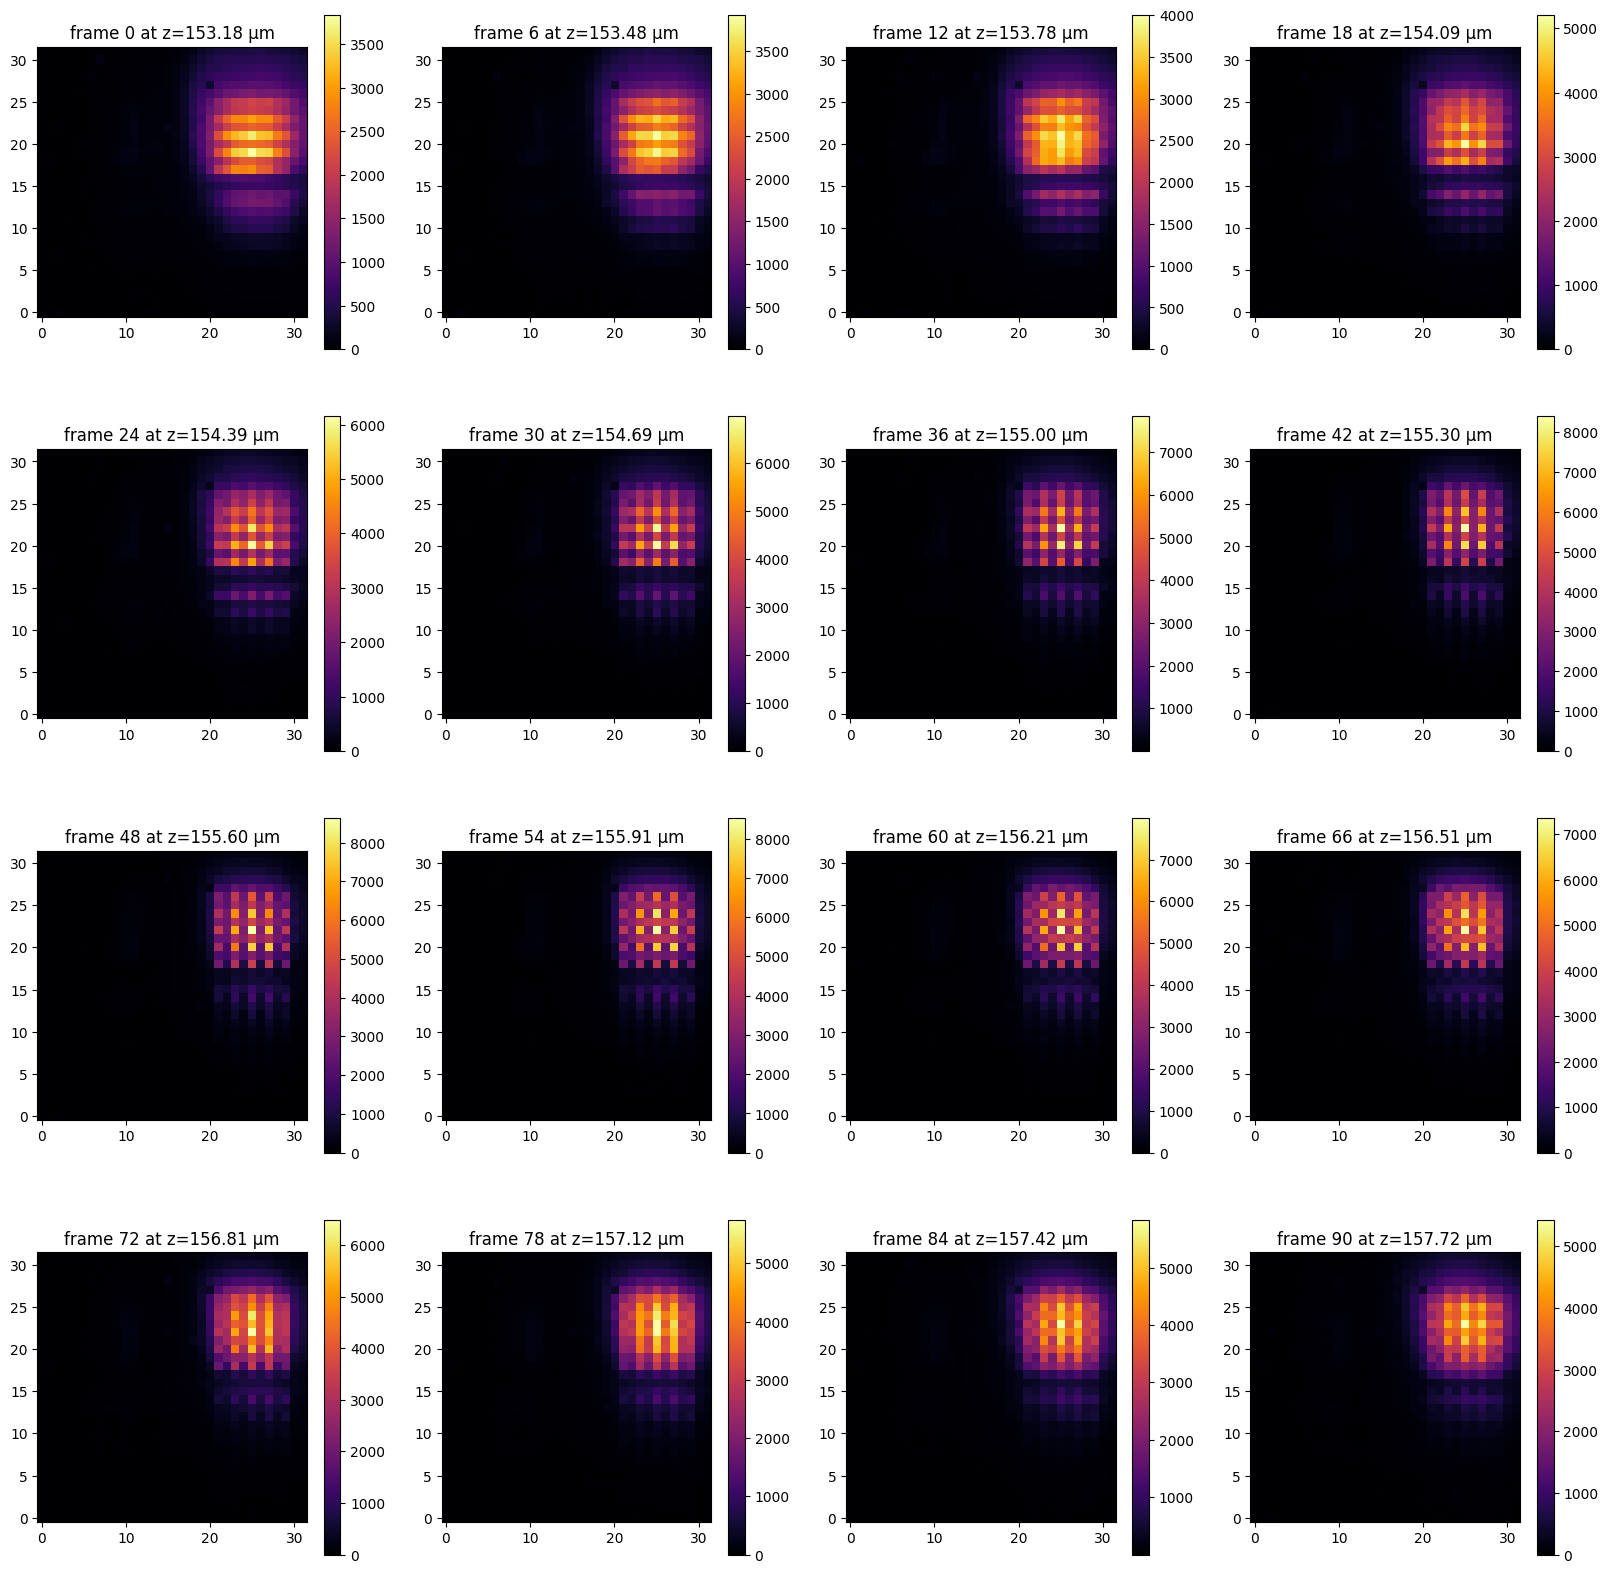

In [4]:
# Retrieve Z sweep data
z_data_remote = opt.spad_scan_data
z_step = {
    'axes':   tuple(z_data_remote[0]['axes']),
    'grids':  {k: np.array(v) * 1e6 for k, v in z_data_remote[0]['grids'].items()},
    'frames': np.array(z_data_remote[0]['frames']),
    'center': {k: v * 1e6 for k, v in z_data_remote[0]['center'].items()},
}

ax = z_step['axes'][0]
z_pos = z_step['grids'][ax]
frames_z = z_step['frames']
print(f'Z sweep: {z_pos[0]:.2f} – {z_pos[-1]:.2f} µm, {len(z_pos)} points, '
      f'frames shape {frames_z.shape}')


plt.subplots(4,4, figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(frames_z[6*i], origin='lower', cmap='inferno')
    plt.title(f'frame {6*i} at z={z_pos[6*i]:.2f} µm')
    plt.colorbar()
plt.show()  

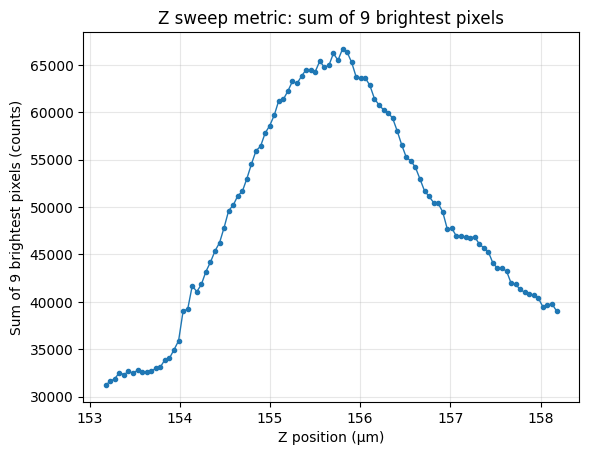

In [5]:
# Sum of the 9 brightest pixels in each Z frame, then plot vs z_pos
# frames_z: (Nz, H, W)
if frames_z.ndim != 3:
    raise ValueError(f"Expected frames_z with shape (Nz, H, W); got {frames_z.shape}")

if len(z_pos) != frames_z.shape[0]:
    raise ValueError(f"len(z_pos)={len(z_pos)} does not match frames_z.shape[0]={frames_z.shape[0]}")

k = 9
#k = 1
flat = frames_z.reshape(frames_z.shape[0], -1)
if flat.shape[1] < k:
    raise ValueError(f"Each frame has only {flat.shape[1]} pixels, cannot take top-{k}.")

# For each frame, take the top-k values without fully sorting
# (np.partition puts the k largest values in the last k positions, in arbitrary order)
bright9_sum = np.partition(flat, -k, axis=1)[:, -k:].sum(axis=1)

plt.figure()
plt.plot(z_pos, bright9_sum, marker='o', ms=3, lw=1)
plt.xlabel('Z position (µm)')
plt.ylabel('Sum of 9 brightest pixels (counts)')
plt.title('Z sweep metric: sum of 9 brightest pixels')
plt.grid(True, alpha=0.3)
plt.show()


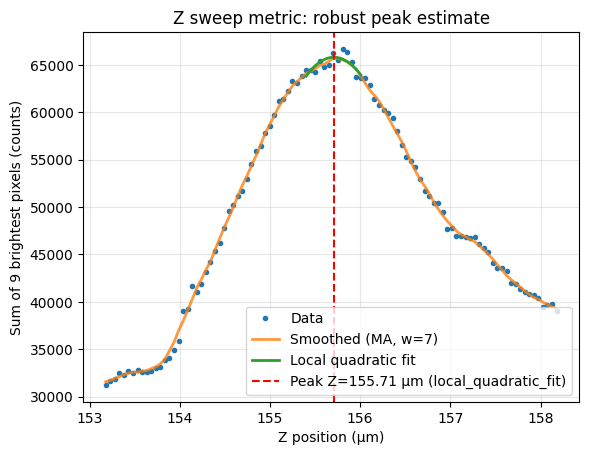

Peak Z estimate: 155.709 µm  (method=local_quadratic_fit)
Coarse peak (smoothed): z=155.704 µm, idx=50
Local fit window idx range: (44, 56), smoothing window=7


In [6]:
# Robust peak finding for bright9_sum vs z_pos (noise-tolerant, automated)


def _moving_average(y: np.ndarray, window: int) -> np.ndarray:
    window = int(max(1, window))
    if window == 1:
        return y.astype(float, copy=False)
    if window % 2 == 0:
        window += 1
    kernel = np.ones(window, dtype=float) / window
    pad = window // 2
    y_pad = np.pad(y.astype(float), (pad, pad), mode='edge')
    return np.convolve(y_pad, kernel, mode='valid')

def find_peak_z_um(
    z_um: np.ndarray,
    y: np.ndarray,
    smooth_window: int | None = None,
    local_half_width: int = 6,
    debug_plot: bool = True,
    ):
    # Cast + drop non-finite points (robust by default)
    z_um = np.asarray(z_um, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(z_um) & np.isfinite(y)
    z_um = z_um[m]
    y = y[m]

    if z_um.size == 0:
        return float('nan'), {'method': 'no_data', 'z_peak_um': float('nan')}
    if z_um.size < 3:
        idx = int(np.argmax(y))
        z_peak_um = float(z_um[idx])
        info = {'method': 'argmax', 'z_peak_um': z_peak_um, 'idx_coarse': idx, 'z_coarse_um': z_peak_um}
        if debug_plot:
            plt.figure()
            plt.plot(z_um, y, 'o', ms=4, label='Data')
            plt.axvline(z_peak_um, color='r', linestyle='--', label=f"Peak Z={z_peak_um:.2f} µm (argmax)")
            plt.xlabel('Z position (µm)')
            plt.ylabel('Sum of 9 brightest pixels (counts)')
            plt.title('Z sweep metric: peak estimate')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
        return z_peak_um, info

    # Default smoothing is conservative and scales with number of points
    if smooth_window is None:
        w = int(max(5, min(21, round(0.07 * z_um.size))))
        smooth_window = w if (w % 2 == 1) else (w + 1)
    smooth_window = int(max(1, smooth_window))
    if smooth_window % 2 == 0:
        smooth_window += 1

    y_smooth = _moving_average(y, smooth_window)
    idx_coarse = int(np.argmax(y_smooth))
    z_coarse = float(z_um[idx_coarse])

    # Local quadratic fit around the coarse peak (use at least 3 points)
    half = int(max(2, local_half_width))
    i0 = max(0, idx_coarse - half)
    i1 = min(z_um.size - 1, idx_coarse + half)
    if (i1 - i0 + 1) < 3:
        i0 = max(0, idx_coarse - 1)
        i1 = min(z_um.size - 1, idx_coarse + 1)
    z_local = z_um[i0 : i1 + 1]
    y_local = y[i0 : i1 + 1]

    # Fit y = p2*z^2 + p1*z + p0 and take vertex if concave
    p2, p1, p0 = np.polyfit(z_local, y_local, deg=2)
    if np.isfinite(p2) and (p2 < 0):
        z_peak_um = float(np.clip(-p1 / (2 * p2), z_local.min(), z_local.max()))
        method = 'local_quadratic_fit'
    else:
        z_peak_um = z_coarse
        method = 'smoothed_argmax'

    info = {
        'method': method,
        'z_peak_um': z_peak_um,
        'smooth_window': smooth_window,
        'idx_coarse': idx_coarse,
        'z_coarse_um': z_coarse,
        'local_slice': (i0, i1),
        'quadratic_coeff': (float(p2), float(p1), float(p0)),
    }

    if debug_plot:
        plt.figure()
        plt.plot(z_um, y, 'o', ms=3, label='Data')
        plt.plot(z_um, y_smooth, '-', lw=2, alpha=0.8, label=f'Smoothed (MA, w={smooth_window})')
        z_dense = np.linspace(z_local.min(), z_local.max(), 200)
        y_dense = p2 * z_dense**2 + p1 * z_dense + p0
        plt.plot(z_dense, y_dense, '-', lw=2, label='Local quadratic fit')
        plt.axvline(z_peak_um, color='r', linestyle='--', label=f"Peak Z={z_peak_um:.2f} µm ({method})")
        plt.xlabel('Z position (µm)')
        plt.ylabel('Sum of 9 brightest pixels (counts)')
        plt.title('Z sweep metric: robust peak estimate')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return float(z_peak_um), info

z_peak_um, z_peak_info = find_peak_z_um(z_pos, bright9_sum, debug_plot=True)
print(f"Peak Z estimate: {z_peak_um:.3f} µm  (method={z_peak_info['method']})")
print(f"Coarse peak (smoothed): z={z_peak_info.get('z_coarse_um', float('nan')):.3f} µm, idx={z_peak_info.get('idx_coarse', -1)}")
if 'local_slice' in z_peak_info:
    print(f"Local fit window idx range: {z_peak_info['local_slice']}, smoothing window={z_peak_info['smooth_window']}")

In [7]:
# Move scanner to the automatically-detected optimal Z (keeps X/Y unchanged)
# Units: µm for convenience in the notebook; hardware expects meters.

use_auto_z = True
z_pos_opt_um = float(z_peak_um) if use_auto_z else 161.3  # µm (manual fallback)

# Start from current target so X/Y stay unchanged
optimal_pos = dict(spad.scanner_target)

# Find the Z axis key (robust to case)
z_key = next((k for k in optimal_pos.keys() if str(k).lower() == 'z'), None)
if z_key is None:
    raise KeyError(f"Couldn't find a 'z' axis in spad.scanner_target keys: {list(optimal_pos.keys())}")

old_z_um = float(optimal_pos[z_key]) * 1e6
optimal_pos[z_key] = z_pos_opt_um * 1e-6

print(f"Moving Z: {old_z_um:.3f} → {z_pos_opt_um:.3f} µm (X/Y unchanged)")
spad.set_target_position(optimal_pos, move_blocking=True)
print('New scanner target:', {k: f"{v*1e6:.3f} µm" for k, v in dict(spad.scanner_target).items()})

Moving Z: 155.678 → 155.709 µm (X/Y unchanged)
New scanner target: {'x': '134.625 µm', 'y': '71.711 µm', 'z': '155.709 µm'}


In [8]:
# Set sequence to XY-only
opt.scan_sequence = (('x', 'y'),)
opt.optimizer_sequence_dimensions = (2,)  # ensure GUI has a 2D widget for ('x','y')
print('Scan sequence set to:', opt.scan_sequence)

# Start XY sweep (centred on current scanner position, which is now at optimal Z)
opt.start_optimize()

t0 = time.time()
while opt.optimizer_running:
    time.sleep(0.5)
    elapsed = time.time() - t0
    print(f'\rXY sweep running... {elapsed:.0f}s', end='', flush=True)

elapsed = time.time() - t0
print(f'\nXY sweep complete in {elapsed:.1f}s')

Scan sequence set to: (('x', 'y'),)
XY sweep running... 80s
XY sweep complete in 79.7s


### Retrieve & analyse XY sweep

XY sweep: x 134.48–134.78 µm (10 pts), y 71.56–71.86 µm (10 pts)
  raw frames shape: (10, 10, 32, 32)


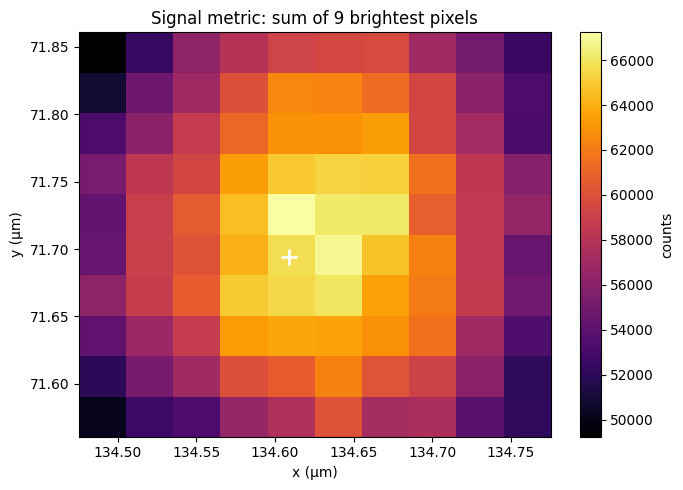

Peak XY (9-brightest metric): (x=134.61 µm, y=71.73 µm)


In [9]:
# Retrieve XY sweep data
xy_data_remote = opt.spad_scan_data
xy_step = {
    'axes':   tuple(xy_data_remote[0]['axes']),
    'grids':  {k: np.array(v) * 1e6 for k, v in xy_data_remote[0]['grids'].items()},
    'frames': np.array(xy_data_remote[0]['frames']),
    'center': {k: v * 1e6 for k, v in xy_data_remote[0]['center'].items()},
}

ax0, ax1 = xy_step['axes']
g0 = xy_step['grids'][ax0]
g1 = xy_step['grids'][ax1]
frames_xy = xy_step['frames']
print(f'XY sweep: {ax0} {g0[0]:.2f}–{g0[-1]:.2f} µm ({len(g0)} pts), '
      f'{ax1} {g1[0]:.2f}–{g1[-1]:.2f} µm ({len(g1)} pts)')
print(f'  raw frames shape: {frames_xy.shape}')

# --- XY metric: sum of the 9 brightest pixels in each frame ---
# frames_xy expected shape: (Nx, Ny, H, W)
if frames_xy.ndim != 4:
    raise ValueError(f'Expected frames array with shape (Nx, Ny, H, W); got {frames_xy.shape}')

have_xy = ('x' in xy_step['grids']) and ('y' in xy_step['grids'])
if not have_xy:
    raise ValueError(f"Expected 'x' and 'y' grids, got keys: {list(xy_step['grids'].keys())}")

x_grid = xy_step['grids']['x']
y_grid = xy_step['grids']['y']
nx, ny = len(x_grid), len(y_grid)

if frames_xy.shape[0] != nx or frames_xy.shape[1] != ny:
    raise ValueError(
        f"frames scan dims are ({frames_xy.shape[0]}, {frames_xy.shape[1]}) but x/y grid lengths are ({nx}, {ny})."
    )

axes = tuple(xy_step['axes'])
if axes != ('x', 'y'):
    raise ValueError(f"Unexpected axes order {axes}; expected ('x','y')")

k = 9
#k = 1 
flat_xy = frames_xy.reshape(nx * ny, -1)
if flat_xy.shape[1] < k:
    raise ValueError(f"Each frame has only {flat_xy.shape[1]} pixels, cannot take top-{k}.")

metric_flat = np.partition(flat_xy, -k, axis=1)[:, -k:].sum(axis=1)
metric_xy = metric_flat.reshape(nx, ny)

# Peak index in (nx, ny)
peak_x_idx, peak_y_idx = np.unravel_index(np.nanargmax(metric_xy), metric_xy.shape)

# For plotting we want metric indexed as [y, x]
metric_yx = metric_xy.T  # (ny, nx)

# Keep peak index compatible with the rest of the notebook: peak_xy_idx indexes (ax0, ax1).
idx_by_axis = {'x': int(peak_x_idx), 'y': int(peak_y_idx)}
peak_xy_idx = (idx_by_axis[ax0], idx_by_axis[ax1])

# Scan-range center idx (for reference marker)
center_x_scan = 0.5 * (x_grid[0] + x_grid[-1])
center_y_scan = 0.5 * (y_grid[0] + y_grid[-1])
x_center_idx = int(np.argmin(np.abs(x_grid - center_x_scan)))
y_center_idx = int(np.argmin(np.abs(y_grid - center_y_scan)))

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

extent = [x_grid[0], x_grid[-1], y_grid[0], y_grid[-1]]
im = ax.imshow(metric_yx, origin='lower', aspect='auto', extent=extent, cmap='inferno')
ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Signal metric: sum of 9 brightest pixels')
fig.colorbar(im, ax=ax, label='counts')

# Mark scan-range center
ax.plot(x_grid[x_center_idx], y_grid[y_center_idx], 'w+', ms=12, mew=2)

plt.tight_layout()
plt.show()

print(f"Peak XY (9-brightest metric): ({ax0}={g0[peak_xy_idx[0]]:.2f} µm, {ax1}={g1[peak_xy_idx[1]]:.2f} µm)")


In [10]:
# Update X/Y to the peak position from the XY sweep (keep Z unchanged)
# ax0/ax1 are the sweep axes; g0/g1 are their grids in µm.

# Build target starting from current scanner target so Z stays unchanged
optimal_pos = dict(spad.scanner_target)

# Helper: match axis key robustly (case-insensitive)
def _match_axis_key(pos_dict, axis_name: str):
    axis_lower = str(axis_name).lower()
    return next((k for k in pos_dict.keys() if str(k).lower() == axis_lower), None)

ax0_key = _match_axis_key(optimal_pos, ax0)
ax1_key = _match_axis_key(optimal_pos, ax1)
if ax0_key is None or ax1_key is None:
    raise KeyError(
        f"Couldn't find axes in spad.scanner_target. Needed ({ax0!r}, {ax1!r}), "
        f"have keys: {list(optimal_pos.keys())}"
    )

x0_um = float(g0[peak_xy_idx[0]])
x1_um = float(g1[peak_xy_idx[1]])

old0_um = float(optimal_pos[ax0_key]) * 1e6
old1_um = float(optimal_pos[ax1_key]) * 1e6

optimal_pos[ax0_key] = x0_um * 1e-6
optimal_pos[ax1_key] = x1_um * 1e-6

print(f"Moving {ax0}: {old0_um:.3f} → {x0_um:.3f} µm")
print(f"Moving {ax1}: {old1_um:.3f} → {x1_um:.3f} µm")
print("(Z unchanged)")

spad.set_target_position(optimal_pos, move_blocking=True)
print('New scanner target:', {k: f"{v*1e6:.3f} µm" for k, v in dict(spad.scanner_target).items()})


Moving x: 134.625 → 134.609 µm
Moving y: 71.711 → 71.727 µm
(Z unchanged)
New scanner target: {'x': '134.609 µm', 'y': '71.727 µm', 'z': '155.709 µm'}
